# Rigol DS1000C Waveform Examples

**Scott Prahl**

**Mar 2026**

In [1]:
%config InlineBackend.figure_format = 'retina'

import numpy as np
import matplotlib.pyplot as plt
import imageio.v3 as iio

from RigolWFM import Wfm, DS1000C_scopes

repo = "https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/"

A list of Rigol scopes in the DS1000C family is:

In [2]:
print(DS1000C_scopes[:])

['C', '1000C', 'DS1000C', 'DS1000CD', 'DS1000MD', 'DS1000M', 'DS1302CA', 'DS1202CA', 'DS1102CA', 'DS1062CA', 'DS1042C']


## DS1202CA

We will start with a `.wfm` file from a Rigol DS1202CA scope. 


### Now for the `.wfm` data

First a textual description.

In [3]:
# raw=true is needed because this is a binary file
wfm_url = repo + "wfm/DS1202CA-A.wfm?raw=true"
w = Wfm.from_url(wfm_url, "1000C")

description = w.describe()
print(description)

    General:
        File Model   = DS1000C
        User Model   = 1000C
        Parser Model = wfm1000c
        Firmware     = unknown
        Filename     = DS1202CA-A.wfm
        Channels     = [1, 2]

    Trigger:
        Mode     = edge
        Source   = CH1
        Derived Level     = 24.00 mV

     Channel 1:
         Coupling =  unknown
            Scale =   200.00 mV/div
           Offset =  -608.00 mV
            Probe =       1X
         Inverted =    False

        Time Base =   10.000 ms/div
           Offset =   -1.600 ms
            Delta =  100.000 µs/point
           Points =     5120

         Count    = [        1,        2,        3  ...      5119,     5120]
           Raw    = [      198,      198,      198  ...       192,      192]
           Times  = [-257.600 ms,-257.500 ms,-257.400 ms  ... 254.300 ms,254.400 ms]
           Volts  = [ 24.00 mV, 24.00 mV, 24.00 mV  ...  72.00 mV, 72.00 mV]

     Channel 2:
         Coupling =  unknown
            Scale =   500.0

downloading 'https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/wfm/DS1202CA-A.wfm?raw=true'


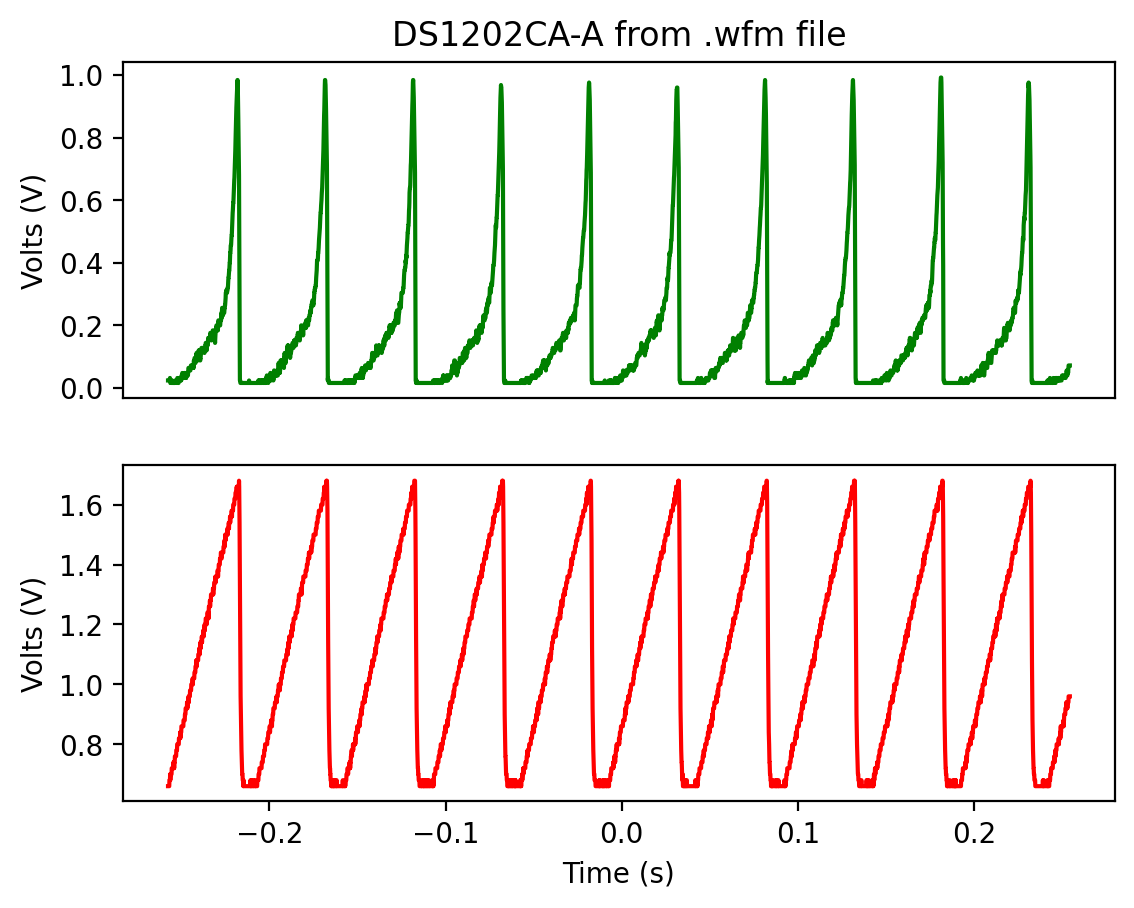

In [4]:
ch = w.channels[0]
plt.subplot(211)
plt.plot(ch.times, ch.volts, color="green")
plt.title("DS1202CA-A from .wfm file")
plt.ylabel("Volts (V)")
# plt.xlim(-0.6,0.6)

plt.xticks([])

ch = w.channels[1]
plt.subplot(212)
plt.plot(ch.times, ch.volts, color="red")
plt.xlabel("Time (s)")
plt.ylabel("Volts (V)")
# plt.xlim(-0.6,0.6)

plt.show()

## DS1042C

<img src="https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/wfm/DS1042C-A.png" width="40%">


### First the `.csv` data

Let's look at what the accompanying `.csv` data looks like.

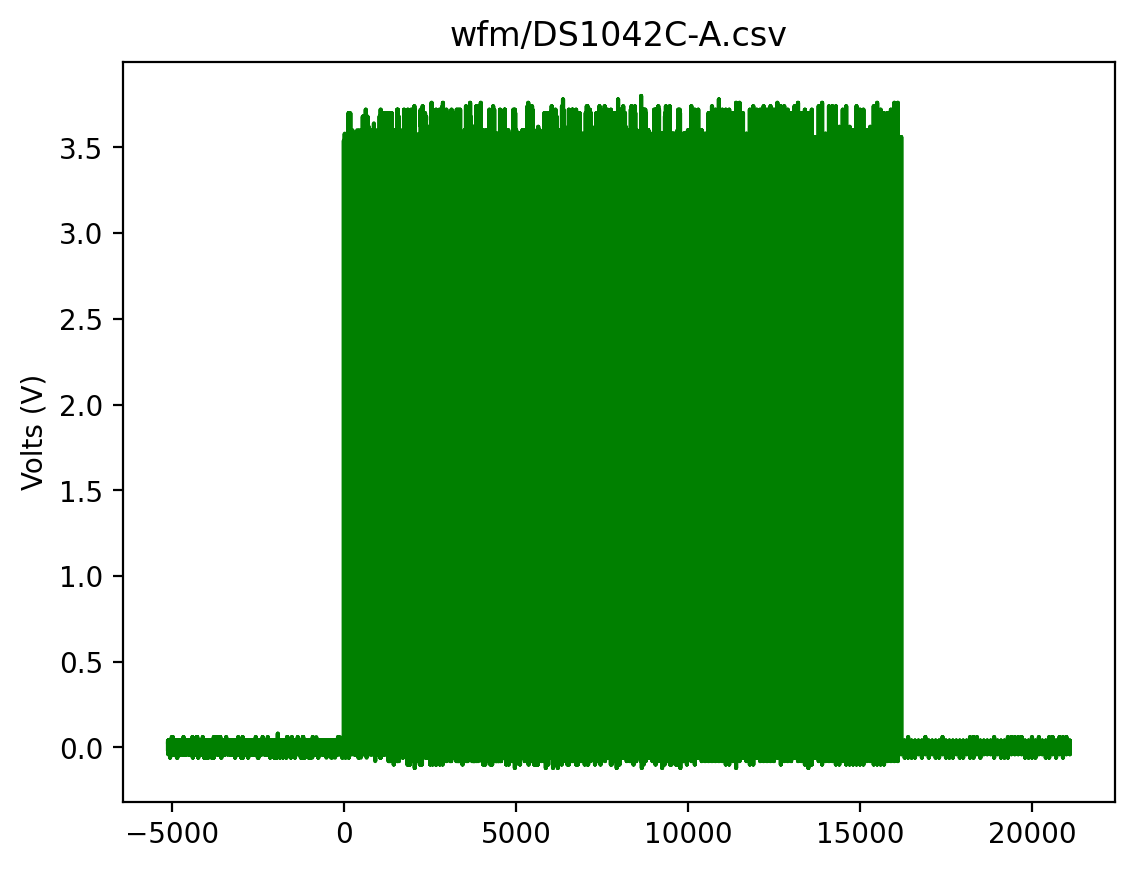

In [5]:
filename = "wfm/DS1042C-A.csv"

csv_data = np.genfromtxt(repo + filename, delimiter=",", skip_header=2).T

plt.plot(csv_data[0] * 1e6, csv_data[1], color="green")
plt.title(filename)
plt.ylabel("Volts (V)")
plt.show()

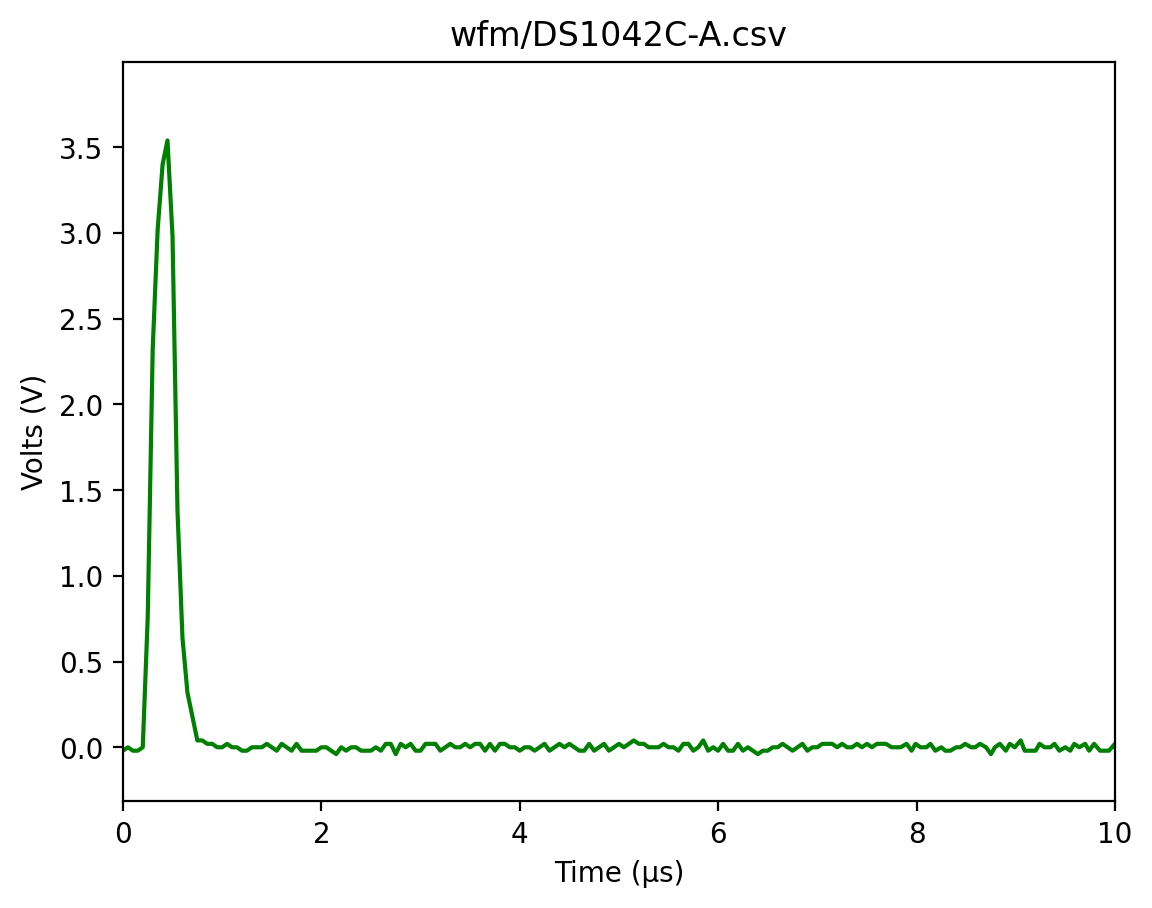

In [6]:
ch = w.channels[0]
plt.plot(csv_data[0] * 1e6, csv_data[1], color="green")

plt.title(filename)
plt.ylabel("Volts (V)")
plt.xlabel("Time (µs)")
plt.xlim(0, 10)
plt.show()

### Now for the `.wfm` data

First a textual description.

In [7]:
# raw=true is needed because this is a binary file
wfm_url = repo + "wfm/DS1042C-A.wfm?raw=true"
w = Wfm.from_url(wfm_url, "1000C")

description = w.describe()
print(description)

    General:
        File Model   = DS1000C
        User Model   = 1000C
        Parser Model = wfm1000c
        Firmware     = unknown
        Filename     = DS1042C-A.wfm
        Channels     = [1]

    Trigger:
        Mode     = pulse
        Source   = CH1
        Derived Level     = -20.00 mV

     Channel 1:
         Coupling =  unknown
            Scale =   500.00 mV/div
           Offset =    -1.82  V
            Probe =      10X
         Inverted =    False

        Time Base =    1.000 ms/div
           Offset =    8.000 ms
            Delta =   50.000 ns/point
           Points =   524288

         Count    = [        1,        2,        3  ...    524287,   524288]
           Raw    = [      215,      215,      215  ...       217,      216]
           Times  = [-5.107 ms,-5.107 ms,-5.107 ms  ... 21.107 ms,21.107 ms]
           Volts  = [ 20.00 mV, 20.00 mV, 20.00 mV  ... -20.00 mV,  0.00  V]




downloading 'https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/wfm/DS1042C-A.wfm?raw=true'


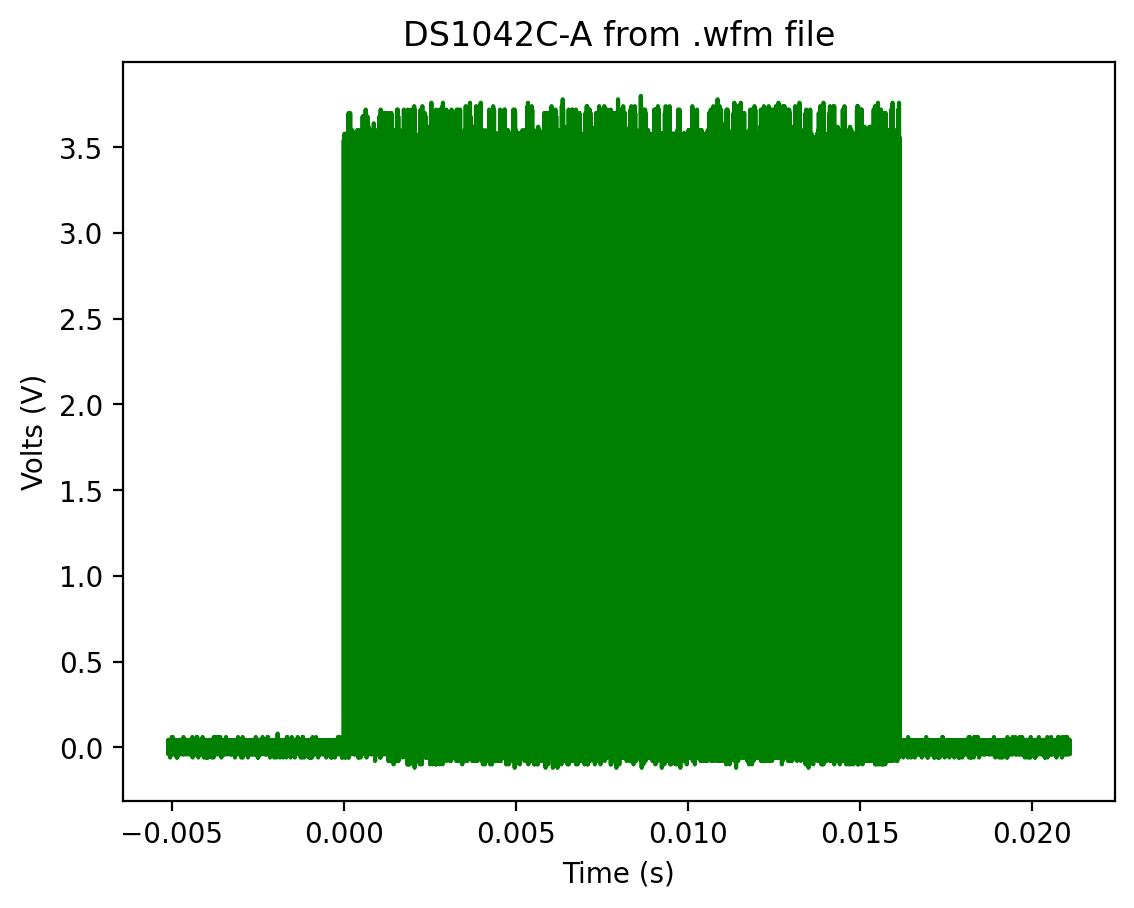

In [8]:
ch = w.channels[0]
plt.plot(ch.times, ch.volts, color="green")
plt.title("DS1042C-A from .wfm file")
plt.ylabel("Volts (V)")
plt.xlabel("Time (s)")

plt.show()

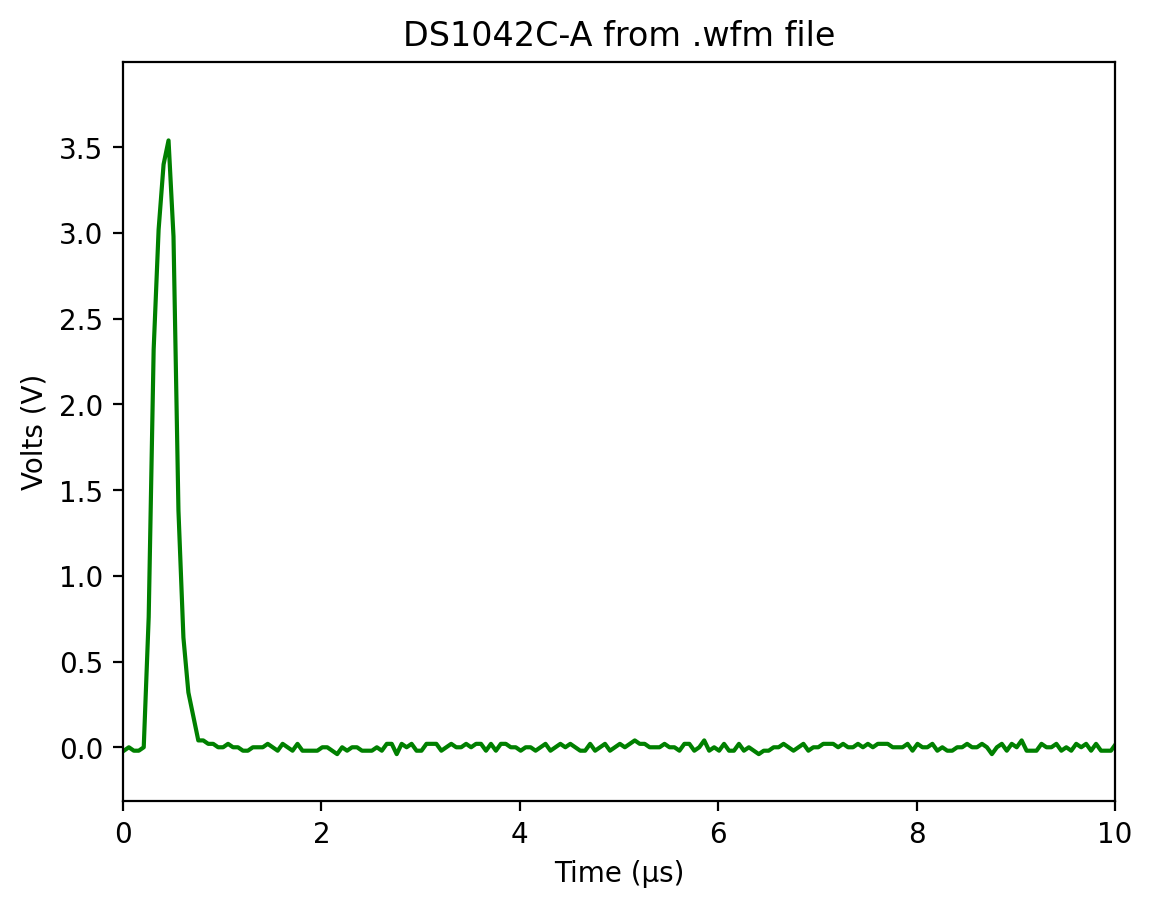

In [9]:
ch = w.channels[0]
plt.plot(ch.times * 1e6, ch.volts, color="green")
plt.title("DS1042C-A from .wfm file")
plt.ylabel("Volts (V)")
plt.xlabel("Time (µs)")
plt.xlim(0, 10)
plt.show()